In [258]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Conv1D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, MaxPooling2D, LSTM, TimeDistributed, Reshape, Dropout
from keras import regularizers

from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import sys
sys.path.append("..")

from Src.data_modules import *


# Data Loading

## Train set

In [299]:
# Rechargement
data_model = np.load('multitaper_data_model_31x3.npz')
X = data_model['X']
y = data_model['y']

In [300]:
X = X.transpose(0, 2, 3, 1)

In [301]:
# Aplatir pour normalisation par échantillon
X_flat = X.reshape(X.shape[0], -1)
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_flat)

# Reshape pour revenir à la forme originale
X = X_normalized.reshape(X.shape)

In [262]:
# 1. Charger et prétraiter les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Test set

In [302]:
# Rechargement
test_data_model = np.load('multitaper_test_data_model_31x3.npz')
X_test = test_data_model['X']

In [303]:
X_test = X_test.transpose(0, 2, 3, 1)

In [304]:
# Aplatir pour normalisation par échantillon
X_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_flat)

# Reshape pour revenir à la forme originale
X_test = X_normalized.reshape(X_test.shape)

In [305]:
# Mélanger les données X et les labels y
X, y = shuffle(X, y, random_state=42)

In [ ]:
# 2. Construire le modèle CNN
model = models.Sequential()

# 2.1. Couche convolutionnelle (avec activation ReLU et normalisation)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(31, 3, 5)))
model.add(layers.MaxPooling2D((2, 2)))  # Couche de pooling pour réduire la dimension spatiale

# 2.2. Autre couche convolutionnelle
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# 2.3. Flatten pour passer à la couche dense
model.add(layers.Flatten())

# 2.4. Couche dense avec 128 unités
model.add(layers.Dense(128, activation='relu'))

# 2.5. Couche de sortie
model.add(layers.Dense(5, activation='softmax'))  # 5 canaux de sortie

# 3. Compiler le modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Utiliser 'binary_crossentropy' pour les problèmes binaires
              metrics=['accuracy'])

# 4. Entraîner le modèle
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# 5. Évaluer le modèle
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

# CNN + LSTM

In [306]:
# Forme d'entrée : (31, 3, 5), où 31 est le nombre de colonnes (timesteps)
input_layer = Input(shape=(31, 3, 5))

# CNN appliqué globalement
cnn = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.1))(input_layer)  # Filtrage par colonne (axe temporel)
cnn = MaxPooling2D((1, 2))(cnn)  # Réduction sur la fréquence uniquement
cnn = Flatten()(cnn)  # Aplatissement des dimensions restantes

# Réorganisation pour fournir à la LSTM
cnn_shape = cnn.shape[1] // 31  # Calcul automatique du nombre de features par timestep
cnn_reshaped = Reshape((31, cnn_shape))(cnn)  # Restructurer en (batch_size, timesteps, features)

# LSTM layer
lstm = LSTM(128, return_sequences=False)(cnn_reshaped)  # Si vous ne voulez pas de séquence pour la sortie LSTM
# lstm = Dropout(0.5)(lstm)

# Fully connected layers
output = Dense(5, activation='sigmoid', kernel_regularizer=regularizers.l2(0.1))(lstm)  # Sortie de forme (batch_size, 5)

# Model creation
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_48 (InputLayer)     │ (None, 31, 3, 5)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 31, 3, 64)      │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 31, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_48 (Flatten)            │ (None, 1984)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_48 (Reshape)            │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_45 (LSTM)                  │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,405 (400.02 KB)

 Trainable params: 102,405 (400.02 KB)

 Non-trainable params: 0 (0.00 B)

## K-Folds

In [238]:
# Définir KFold pour la validation croisée (5 folds ici)
kf = KFold(n_splits=5)

# Variables pour calculer la moyenne des scores de chaque fold
accuracy_per_fold = []
loss_per_fold = []

# Définir la structure de votre modèle
def create_model():
    input_layer = Input(shape=(31, 3, 5))

    # CNN appliqué globalement
    cnn = Conv2D(64, (1, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.1))(input_layer)  
    cnn = MaxPooling2D((1, 2))(cnn)  # Réduction sur la fréquence uniquement
    cnn = Flatten()(cnn)  # Aplatissement des dimensions restantes

    # Réorganisation pour fournir à la LSTM
    cnn_shape = cnn.shape[1] // 31  # Calcul automatique du nombre de features par timestep
    cnn_reshaped = Reshape((31, cnn_shape))(cnn)  # Restructurer en (batch_size, timesteps, features)

    # LSTM layer avec Dropout pour éviter le surapprentissage
    lstm = LSTM(128, return_sequences=False)(cnn_reshaped)
    lstm = Dropout(0.5)(lstm)

    # Fully connected layer
    output = Dense(5, activation='sigmoid', kernel_regularizer=regularizers.l2(0.1))(lstm)

    # Création du modèle
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Pour chaque fold de KFold
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f"Training fold {fold_no}...")

    # Séparation des données en train et validation
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Créer un nouveau modèle pour ce fold
    model = create_model()

    # Entraînement du modèle pour ce fold
    history = model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold), epochs=10, batch_size=10)

    # Évaluation du modèle pour ce fold
    val_loss, val_acc = model.evaluate(X_val_fold, y_val_fold)
    print(f"Validation accuracy for fold {fold_no}: {val_acc:.4f}")
    accuracy_per_fold.append(val_acc)
    loss_per_fold.append(val_loss)

    fold_no += 1

# Calcul des performances moyennes
print(f"Average accuracy across folds: {np.mean(accuracy_per_fold):.4f}")
print(f"Average loss across folds: {np.mean(loss_per_fold):.4f}")

Training fold 1...
Epoch 1/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.3269 - loss: 0.5646 - val_accuracy: 0.2184 - val_loss: 0.3663
Epoch 2/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3267 - loss: 0.3529 - val_accuracy: 0.2184 - val_loss: 0.3105
Epoch 3/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3730 - loss: 0.3204 - val_accuracy: 0.4372 - val_loss: 0.3168
Epoch 4/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3985 - loss: 0.3074 - val_accuracy: 0.4786 - val_loss: 0.2930
Epoch 5/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4444 - loss: 0.2946 - val_accuracy: 0.5197 - val_loss: 0.2814
Epoch 6/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4299 - loss: 0.2925 - val_accuracy: 0.5209 - val_loss: 0.2836
Epoch 7/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4286 - loss: 0.2873 - val_accuracy: 0.4830 - val_loss: 0.2744
Epoch 8/10
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accurac

## Entrainement

In [307]:
# Calcul des poids de classe
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train.flatten())
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

In [296]:
history = model.fit(X_train, y_train, batch_size=32, epochs=5, validation_split=0.2, class_weight=class_weights_dict)

Epoch 1/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3994 - loss: 0.7487 - val_accuracy: 0.5684 - val_loss: 0.3363
Epoch 2/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5117 - loss: 0.3707 - val_accuracy: 0.5001 - val_loss: 0.3281
Epoch 3/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5106 - loss: 0.3539 - val_accuracy: 0.5171 - val_loss: 0.3037
Epoch 4/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4832 - loss: 0.3444 - val_accuracy: 0.2377 - val_loss: 0.2990
Epoch 5/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4573 - loss: 0.3397 - val_accuracy: 0.5432 - val_loss: 0.2992


In [308]:
model.fit(X, y, batch_size=32, epochs=50, validation_split=0.2, class_weight=class_weights_dict)

Epoch 1/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4068 - loss: 0.6618 - val_accuracy: 0.4781 - val_loss: 0.3201
Epoch 2/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4879 - loss: 0.3466 - val_accuracy: 0.4537 - val_loss: 0.2965
Epoch 3/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4509 - loss: 0.3263 - val_accuracy: 0.5326 - val_loss: 0.2868
Epoch 4/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4776 - loss: 0.3143 - val_accuracy: 0.2317 - val_loss: 0.2888
Epoch 5/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4478 - loss: 0.3105 - val_accuracy: 0.5629 - val_loss: 0.2883
Epoch 6/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4683 - loss: 0.3022 - val_accuracy: 0.2319 - val_loss: 0.2692
Epoch 7/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4677 - loss: 0.2964 - val_accuracy: 0.5128 - val_loss: 0.2661
Epoch 8/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4608 - loss: 0

In [292]:
# Prédictions sur l'ensemble de test
y_pred = (model.predict(X_test) > 0.5)  # Pour une classification binaire

y_pred = y_pred.flatten().tolist()
try:
    y_test = y_test.flatten().tolist()
except AttributeError:
    pass

# Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy: 0.9214567681140965

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.84      0.89     31157
           1       0.90      0.98      0.94     47373

    accuracy                           0.92     78530
   macro avg       0.93      0.91      0.92     78530
weighted avg       0.92      0.92      0.92     78530

Score Kappa : 0.8323455589231322


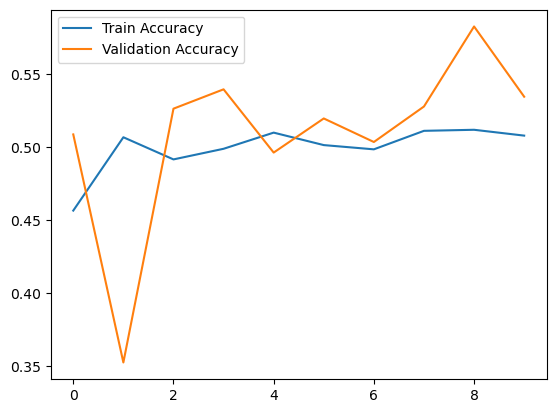

In [293]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

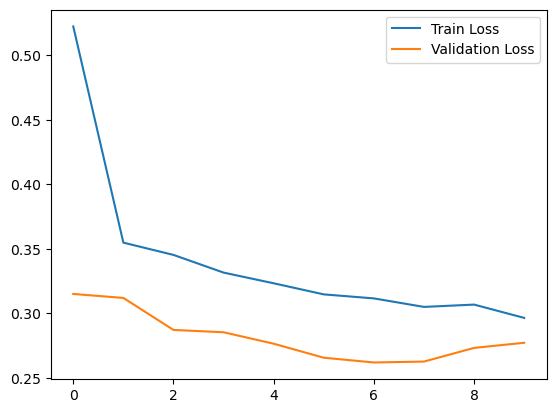

In [294]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# Submission

In [309]:
def format_array_to_target_format(array, record_number, nb_points):

    formatted_target = []
    for i in range(5):
        channel_encoding = (i + 1) * 100000
        record_number_encoding = record_number * 1000000
        for j in range(nb_points):
            formatted_target.append(
                {
                    "identifier": record_number_encoding + channel_encoding + j,
                    "target": array[j][i],
                }
            )
    return formatted_target

In [310]:
results = []

# Set 4
X_test_4 = X_test[:13204]
preds = (model.predict(X_test_4) > 0.5)
sublists = [preds[i:i + 13204] for i in range(0, len(preds), 13204)]

formatted_preds = format_array_to_target_format(sublists[0], 4, 13204)

results.extend(formatted_preds)

# Set 5
X_test_5 = X_test[13204:]
preds = (model.predict(X_test_5) > 0.5)
sublists = [preds[i:i + 9319] for i in range(0, len(preds), 9319)]

formatted_preds = format_array_to_target_format(sublists[0], 5, 9319)

results.extend(formatted_preds)

df = pd.DataFrame(results)


df['target'] = df['target'].apply(lambda x: 1 if x == True else (0 if x == False else x))

df.to_csv("../Results/submission_cnn_lstm_big_l2_b32_e50_k33.csv",index = False)

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
